<a href="https://colab.research.google.com/github/LeonimerMelo/Reinforcement-Learning/blob/Policy-Gradient/REINFORCE_Policy_Gradient_Algorithm_(RL)_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#REINFORCE - Policy Gradient Algorithm

O algoritmo REINFORCE, desenvolvido por Ronald J. Williams em 1992 em seu artigo "*Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning*" [[1]](https://link.springer.com/article/10.1007/BF00992696), aprende uma política parametrizada que produz probabilidades de ações a partir de estados. Os agentes usam essa política diretamente para agir em um ambiente.

A ideia central é que, durante o aprendizado, **ações que resultaram em bons resultados** devem **se tornar mais prováveis** — essas ações são positivamente reforçadas. Por outro lado, ações que resultaram em maus resultados devem se tornar menos prováveis. Se o aprendizado for bem-sucedido, ao longo de muitas iterações, as probabilidades das ações produzidas pela política se ajustam para uma distribuição que resulta em um bom desempenho no ambiente. **As probabilidades das ações são alteradas seguindo o gradiente da política**, portanto, o REINFORCE é conhecido como `algoritmo de gradiente de política`.

O algoritmo necessita de três componentes:  
1. Uma política parametrizada  
2. Um objetivo a ser maximizado  
3. Um método para atualizar os parâmetros da política  

O núcleo do algoritmo REINFORCE é o gradiente da política. O gradiente da política fornece uma maneira de estimar o gradiente do objetivo em relação aos parâmetros da política. Este é um passo crucial, pois o gradiente da política é usado para modificar os parâmetros da política de forma a maximizar o objetivo.

##Introdução
O algoritmo **REINFORCE** é uma abordagem clássica de aprendizado por reforço baseada em gradiente de política, introduzida por Ronald J. Williams em 1992. Ele é projetado para otimizar diretamente uma política parametrizada $\pi_\theta(a|s)$, onde $a$ representa uma ação, $s$ um estado, e $\theta$ são os parâmetros ajustáveis da política.

### Visão Geral do Algoritmo

1. **Política Parametrizada:**
   - O REINFORCE aprende uma política estocástica, ou seja, em vez de selecionar ações determinísticas, ele atribui uma probabilidade a cada ação em um estado específico.
   - A política é representada como $\pi_\theta(a|s)$, que é uma função parametrizada por $\theta$, frequentemente modelada por redes neurais.

2. **Objetivo:**
   - Maximizar o retorno esperado $J(\theta)$, definido como:
$$
J(\theta) = \mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^\infty \gamma^t R_t\right]
$$
     onde:
     - $\gamma \in [0, 1]$ é o fator de desconto,
     - $R_t$ é a recompensa obtida no tempo $t$,
     - A expectativa é tomada sobre a distribuição de trajetórias geradas pela política $\pi_\theta$.

3. **Gradiente da Política:**
   - O REINFORCE utiliza o **teorema do gradiente da política** para derivar uma expressão para o gradiente de $J(\theta)$:
$$
\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\nabla_\theta \log \pi_\theta(a|s) G_t\right],
$$
onde $G_t = \sum_{k=t}^\infty \gamma^{k-t} R_k$ é o retorno acumulado a partir do tempo $t$.

4. **Atualização dos Parâmetros:**
   - Os parâmetros da política são atualizados por **gradiente ascendente**, pois o objetivo é maximizar $J(\theta)$:
$$
\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a|s) G_t
$$
onde $\alpha$ é a taxa de aprendizado.

### Intuição do Funcionamento

- A ideia principal é reforçar ações que levam a altos retornos $G_t$, aumentando suas probabilidades. Isso é feito ajustando os parâmetros $\theta$ na direção do gradiente positivo, ponderado pelas recompensas acumuladas.
- **Log-Probabilidade:** A inclusão do termo $\log \pi_\theta(a|s)$ conecta diretamente a probabilidade de escolher uma ação aos retornos observados, permitindo que o aprendizado seja direcionado.

### Benefícios

1. **Simplicidade:**
   - O REINFORCE é conceitualmente simples e direto, tornando-o um ponto de partida comum no aprendizado por reforço baseado em gradientes.
2. **Exploração Automática:**
   - Como a política é estocástica, o REINFORCE explora naturalmente diferentes ações, sem necessidade de estratégias adicionais de exploração.

### Desafios

1. **Alta Variância no Gradiente:**
   - O retorno $G_t$ pode ser ruidoso, especialmente em ambientes com recompensas esparsas, levando a uma alta variância na estimativa do gradiente.
   - Isso pode causar instabilidade e tornar o treinamento mais lento.

2. **Recompensas Não Escaladas:**
   - Recompensas de diferentes magnitudes podem afetar a estabilidade do aprendizado. Normalizar recompensas ou usar métodos de base pode mitigar esse problema.

3. **Dependência de Fator de Desconto ($\gamma$):**
   - A escolha de $\gamma$ impacta fortemente o aprendizado, pois controla o equilíbrio entre recompensas imediatas e futuras.

### Extensões e Melhorias

Vários algoritmos foram desenvolvidos para superar as limitações do REINFORCE:

1. **Baseline Subtraction:**
   - Reduz a variância subtraindo uma baseline $b(s)$ do retorno $G_t$, onde $b(s)$ é tipicamente uma estimativa do valor do estado:
$$
\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\nabla_\theta \log \pi_\theta(a|s) (G_t - b(s))\right]
$$

2. **Algoritmos Advantage Actor-Critic (A2C/A3C):**
   - Introduzem a vantagem $A(s, a) = G_t - V(s)$, onde $V(s)$ é o valor esperado do estado $s$. Isso melhora a eficiência do aprendizado.

3. **Trust Region Policy Optimization (TRPO) e Proximal Policy Optimization (PPO):**
   - Melhoram a estabilidade ao restringir as atualizações da política dentro de limites controlados.

### Aplicações

O REINFORCE é usado em tarefas de controle e otimização, incluindo:
- Controle robótico.
- Jogos (como aprendizado em ambientes da OpenAI Gym).
- Sistemas de recomendação com aprendizado de políticas.

Apesar de suas limitações, o REINFORCE desempenha um papel fundamental na história e desenvolvimento do aprendizado por reforço baseado em gradientes.

##Política  
Uma política $\pi$ é uma função que mapeia estados para probabilidades de ações, utilizada para amostrar uma ação $a \sim \pi(s)$. No REINFORCE, um agente aprende uma política e a utiliza para agir em um ambiente.

**Uma boa política é aquela que maximiza as recompensas acumuladas**. A ideia central do algoritmo é aprender uma boa política, o que implica realizar aproximação de funções. Redes neurais são aproximadores de funções poderosos e flexíveis, por isso podemos **representar uma política usando uma rede neural profunda** composta por parâmetros aprendíveis $\theta$ (pesos). Isso é frequentemente chamado de **rede de política** $\pi_\theta$. Dizemos que a política é parametrizada por $\theta$.

Cada conjunto específico de valores dos parâmetros da rede de política representa uma política particular. Para entender por que, considere $\theta_1 \neq \theta_2$. Para um dado estado $s$, redes de políticas diferentes podem gerar conjuntos diferentes de probabilidades de ações, ou seja, $\pi_{\theta_1}(s) \neq \pi_{\theta_2}(s)$. Os mapeamentos de estados para probabilidades de ações são diferentes, então dizemos que $\pi_{\theta_1}$ e $\pi_{\theta_2}$ são políticas diferentes. Uma única rede neural, portanto, é capaz de representar muitas políticas diferentes.

Formulada dessa maneira, **o processo de aprender uma boa política corresponde a buscar um bom conjunto de valores para** $\theta$ (pesos). Por essa razão, é importante que a rede de política seja diferenciável. O mecanismo pelo qual a política é aprimorada é por meio da **ascensão do gradiente** no espaço dos parâmetros.

##Função Objetivo  
Agora definimos o objetivo maximizado por um agente no algoritmo REINFORCE. Um objetivo pode ser entendido como a meta de um agente, como vencer um jogo ou obter a maior pontuação possível. Primeiramente, introduzimos o conceito de retorno, que é calculado usando uma trajetória. Em seguida, usamos isso para formular o objetivo.

Um agente atuando em um ambiente gera uma **trajetória**, que contém uma sequência de recompensas juntamente com os estados e ações. Uma trajetória é denotada por:  
$$
\tau = s_0, a_0, r_0, \ldots, s_T, a_T, r_T
$$

O **retorno** de uma trajetória $R_t(\tau)$ é definido como a soma de recompensas descontadas desde o instante de tempo $t$ até o final da trajetória, conforme mostrado na Equação:  
$$
R_t(\tau) = \sum_{t' = t}^T \gamma^{t' - t} r_{t'}
$$

Observe que a soma começa no instante de tempo $t$, mas a potência do fator de desconto $\gamma$ começa em 0. Por isso, é necessário ajustar a potência com base no instante inicial $t$, usando $t' - t$.

Quando $t = 0$, o retorno é simplesmente o retorno da trajetória completa. Para simplificar, isso também é escrito como $R_0(\tau) = R(\tau)$.  

O **objetivo** é o retorno esperado sobre todas as trajetórias completas geradas por um agente. Isso é definido na Equação:  
$$
J(\pi_\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)] = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^T \gamma^t r_t \right]
$$
A Equação acima afirma que a expectativa é calculada sobre muitas trajetórias amostradas a partir de uma política, ou seja, $\tau \sim \pi_\theta$. Essa expectativa se aproxima do valor verdadeiro à medida que mais amostras são coletadas, e está vinculada à política específica $\pi_\theta$ utilizada.

### Explicação Intuitiva  

- **Trajetória ($\tau$)**: Representa o caminho que o agente percorre no ambiente, incluindo estados ($s$), ações ($a$) e recompensas ($r$).  
- **Retorno ($R_t(\tau)$)**: Mede o valor total das recompensas futuras (descontadas) que o agente espera a partir do instante $t$.  
- **Função Objetivo ($J(\pi_\theta)$)**: O objetivo do agente é maximizar o retorno esperado, ou seja, aprender uma política que gere trajetórias com altos valores acumulados de recompensa.

## O Gradiente da Política  

Agora definimos a política $\pi_\theta$ e o objetivo $J(\pi_\theta)$, que são dois componentes cruciais para a derivação do algoritmo de gradiente de política. **A política fornece uma maneira para o agente agir, e o objetivo estabelece um alvo a ser maximizado**.

O componente final do algoritmo é o **gradiente da política**. Formalmente, dizemos que um algoritmo de gradiente de política resolve o seguinte problema:  
$$
\max_{\theta} J(\pi_\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)]
$$

Para maximizar o objetivo, realizamos a **subida por gradiente** nos parâmetros da política $\theta$. Lembre-se, do cálculo diferencial, que o gradiente aponta na direção de maior subida. Para melhorar o objetivo, calculamos o gradiente e o utilizamos para atualizar os parâmetros, como mostrado na Equação:  
$$
\theta \leftarrow \theta + \alpha \nabla_\theta J(\pi_\theta)
$$  
onde:
- $\alpha$ é a taxa de aprendizado,
- $\nabla_\theta J(\pi_\theta)$ é o gradiente do objetivo em relação aos parâmetros da política.

Essa atualização ajusta os parâmetros $\theta$ na direção que maximiza o retorno esperado $J(\pi_\theta)$.

O termo $\nabla_\theta J(\pi_\theta)$ é conhecido como o **gradiente da política**. Ele é definido na Equação:  
$$
\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^T R_t(\tau) \nabla_\theta \log \pi_\theta(a_t | s_t)\right]
$$

<!--\tag{2.5} para colocar número nas equações  -->

O termo $\pi_\theta(a_t | s_t)$ é a probabilidade da ação tomada pelo agente no passo de tempo $t$. A ação é amostrada da política, $a_t \sim \pi_\theta(s_t)$. O lado direito da equação afirma que o gradiente do logaritmo da probabilidade da ação em relação a $\theta$ é multiplicado pelo retorno $R_t(\tau)$.

A Equação afirma que o gradiente do objetivo é equivalente à soma esperada dos gradientes dos logaritmos das probabilidades das ações $a_t$, multiplicada pelos respectivos retornos $R_t(\tau)$.

O **gradiente da política** é o mecanismo pelo qual as probabilidades das ações produzidas pela política são alteradas. Se o retorno $R_t(\tau) > 0$, então a probabilidade da ação $\pi_\theta(a_t | s_t)$ é aumentada; inversamente, se o retorno $R_t(\tau) < 0$, então a probabilidade da ação $\pi_\theta(a_t | s_t)$ é diminuída. Ao longo de muitas atualizações
da Equação, a política aprenderá a produzir ações que resultam em altos valores de $R_t(\tau)$.

A Equação é a base de todos os métodos de gradiente de política. O REINFORCE foi o primeiro algoritmo a utilizá-la em sua forma mais simples. Algoritmos mais novos implementam com base nisto, modificando a função para melhorar o desempenho.

##Amostragem Monte Carlo
O algoritmo **REINFORCE** estima numericamente o gradiente da política usando amostragem Monte Carlo.

A amostragem Monte Carlo refere-se a qualquer método que utiliza amostragem aleatória para gerar dados usados para aproximar uma função. Em essência, é apenas "aproximação com amostragem aleatória". É uma técnica que se popularizou graças a Stanislaw Ulam, um matemático que trabalhou no laboratório de pesquisa de Los Alamos na década de 1940.

Para entender como a amostragem Monte Carlo funciona, vamos passar por um exemplo de como ela pode ser usada para estimar o valor de $\pi$ (a constante matemática)—a razão entre a circunferência e o diâmetro de um círculo. Uma abordagem de Monte Carlo para resolver esse problema é pegar um círculo de raio $r = 1$ centrado na origem e inscrevê-lo em um quadrado. As áreas do círculo e do quadrado são $\pi r^2$ e $(2r)^2$, respectivamente. Assim, a razão entre essas áreas é simplesmente:
$$
\frac{\text{área do círculo}}{\text{área do quadrado}} = \frac{\pi r^2}{(2r)^2} = \frac{\pi}{4}
$$

Numericamente, o quadrado tem uma área de 4, mas como ainda não sabemos o valor de $\pi$, a área do círculo é desconhecida. Vamos considerar um quadrante. Para obter uma estimativa de $\pi$, amostramos muitos pontos dentro do quadrado usando uma distribuição aleatória uniforme. Um ponto $(p_x, p_y)$ que cai dentro do círculo tem uma distância menor que 1 da origem—ou seja, $(x - 0)^2 + (y - 0)^2 \leq 1$. Isso é mostrado na Figura abaixo. Usando isso, se contarmos o número de pontos dentro do círculo e depois contarmos o número total de pontos amostrados, a razão entre eles será aproximadamente igual à Equação acima. Ao amostrar iterativamente mais pontos e atualizar a razão, nossa estimativa se aproximará do valor preciso. Multiplicando essa razão por 4, obtemos o valor estimado de $\pi \approx 3,14159$.

<center>
<img src='https://drive.google.com/uc?id=1gtT1z2QWps_SCsyYhsVp7NkE_L6lcOXj' width=300>
</center>

In [ ]:
import numpy as np
t_circ = 0
t_quad = 100000
for i in range(t_quad):
  x = np.random.rand()
  y = np.random.rand()
  d = np.sqrt(x**2 + y**2)
  if d <= 1:
    t_circ += 1
pi = 4 * t_circ / t_quad
print('pi ~', pi)

pi ~ 3.14164


Agora, vamos voltar ao **Deep RL** e ver como a amostragem **Monte Carlo** pode ser usada para estimar numericamente o gradiente da política. É bastante simples. A expectativa $ \mathbb{E}_{\tau \sim \pi_\theta} $ implica que, à medida que mais trajetórias $ \tau $ são amostradas usando uma política $ \pi_\theta $ e calculadas a média, elas se aproximam do gradiente real da política $ \nabla_\theta J(\pi_\theta) $. Em vez de amostrar muitas trajetórias por política, podemos amostrar apenas uma, como mostrado na Equação:
$$
\nabla_\theta J(\pi_\theta) \approx \sum_{t=0}^T R_t(\tau) \nabla_\theta \log \pi_\theta(a_t | s_t)
$$

É assim que o **gradiente da política** é implementado—como uma estimativa Monte Carlo sobre trajetórias amostradas.

##Categorical Distribution
Uma **distribuição categórica** é um tipo de distribuição de probabilidade que descreve a probabilidade de cada possível resultado em um conjunto finito de categorias. Ela é comumente usada em cenários onde os dados são discretos e podem ser classificados em grupos mutuamente exclusivos, como cores, espécies ou respostas de uma pesquisa. Em python é utilizada a função `softmax` para a distribuição categórica.

---

### Principais Propriedades de uma Distribuição Categórica
1. **Conjunto Finito de Categorias**: A distribuição aplica-se a $ k $ categorias, onde $ k $ é finito.
2. **Probabilidades**: Cada categoria tem uma probabilidade associada, $ p_1, p_2, \dots, p_k $, que satisfazem:
   $$
   p_i \geq 0 \quad \text{para todo } i, \quad \text{e} \quad \sum_{i=1}^k p_i = 1
   $$
3. **Variável Aleatória**: A variável aleatória representa o índice da categoria.

---

### Função de Massa de Probabilidade (PMF)
A função de massa de probabilidade de uma distribuição categórica é dada por:
$$
P(X = i) = p_i, \quad \text{para } i = 1, 2, \dots, k
$$
onde $ X $ é a variável aleatória e $ p_i $ é a probabilidade da categoria $ i $.

---

### Exemplos de Distribuições Categóricas
1. **Jogadas de Dados**: Um dado justo de seis lados pode ser modelado como uma distribuição categórica com $ k = 6 $ e $ p_i = \frac{1}{6} $ para todos os $ i $.
2. **Respostas de Pesquisa**: Se uma pesquisa pergunta qual é a bebida preferida (chá, café, água), os resultados podem ser modelados como uma distribuição categórica em três categorias.

---

### Relação com Outras Distribuições
1. **Distribuição Multinomial**: A distribuição categórica é um caso especial da distribuição multinomial onde há apenas um experimento ($ n = 1 $).
2. **Distribuição Bernoulli**: A distribuição categórica reduz-se à distribuição Bernoulli quando há apenas duas categorias ($ k = 2 $).

---

### Aplicações
- **Aprendizado de Máquina**: Utilizada em tarefas de classificação e como base para modelos como Naive Bayes e classificadores softmax.
- **Processamento de Linguagem Natural**: Para modelar distribuições de palavras em textos.
- **Análise Estatística**: Na análise de dados categóricos e tabelas de contingência.

## Função Logit
A função **logit** e suas propriedades são centrais na estatística, especialmente na regressão logística e em outros modelos probabilísticos. Aqui está um resumo traduzido:

O **logit** de uma probabilidade $ p $ é definido como:
$$
L = \ln\left(\frac{p}{1-p}\right)
$$
- $ \frac{p}{1-p} $ é chamado de **odds** (razão de chances), representando a razão entre a probabilidade de sucesso e a probabilidade de fracasso.
- O logaritmo natural dos odds é chamado de **log-odds** ou **logit**.

### Função Inversa do Logit
A **função inversa do logit** transforma logits de volta em probabilidades:
$$
p = \frac{1}{1 + e^{-L}}
$$
Essa função também é conhecida como **função sigmoide** por causa de seu formato em "S".

### Principais Propriedades
1. **Intervalo de Probabilidades**:
   - As probabilidades $ p $ estão limitadas entre 0 e 1: $ p \in [0, 1] $.
   - Os logits $ L $ são ilimitados: $ L \in (-\infty, \infty) $.

2. **Interpretação**:
   - Um logit de $ L = 0 $ corresponde a $ p = 0.5 $. Isso indica chances iguais de sucesso e fracasso ($ \frac{p}{1-p} = 1 $).
   - Logits negativos ($ L < 0 $) correspondem a probabilidades menores que 0.5.
   - Logits positivos ($ L > 0 $) correspondem a probabilidades maiores que 0.5.

3. **Simetria**:
   - A relação entre logits e probabilidades é simétrica em torno de $ p = 0.5 $ (ou $ L = 0 $).
   - Por exemplo:
     - $ L = -0.2 $ corresponde a $ p = 0.45 $.
     - $ L = 0.2 $ corresponde a $ p = 0.55 $.
   - A diferença absoluta dessas probabilidades em relação a 0.5 é idêntica.

### Aplicações
- A função logit é amplamente utilizada na regressão logística, que modela a relação entre um resultado binário e uma ou mais variáveis preditoras.
- Ela oferece uma medida interpretável (log-odds) que escala linearmente, facilitando a análise estatística e os modelos de aprendizado de máquina.

Abaixo temos exemplos em Python para trabalhar com distribuições categóricas, usando bibliotecas como `numpy` e `scipy`.

---

### **1. Simulando uma Distribuição Categórica com NumPy**

In [ ]:
import numpy as np
from collections import Counter

# Definindo as categorias e suas probabilidades
categories = ['chá', 'café', 'água']
probabilities = [0.2, 0.5, 0.3]  # As probabilidades devem somar 1

# Gerando uma amostra aleatória de tamanho 10
samples = np.random.choice(categories, size=10, p=probabilities)

print("Amostras geradas:", samples)
count = Counter(samples)
print("Quantidades:", count)

Amostras geradas: ['café' 'café' 'água' 'água' 'água' 'chá' 'café' 'água' 'café' 'café']
Quantidades: Counter({'café': 5, 'água': 4, 'chá': 1})


### **2. Calculando a Probabilidade com Scipy**
Se quisermos calcular a probabilidade de uma única observação de uma distribuição categórica, podemos usar `scipy.stats.multinomial`.

In [ ]:
from scipy.stats import multinomial

# Probabilidades das categorias
probabilities = [0.2, 0.5, 0.3]

# Calculando a probabilidade de observar a categoria 'café' (índice 1)
prob = multinomial.pmf([0, 1, 0], n=1, p=probabilities)

print("Probabilidade de observar 'café':", prob)

Probabilidade de observar 'café': 0.5


### **3. Ajustando um Modelo Categórico com Dados**
Podemos usar bibliotecas como `pandas` para ajustar as probabilidades de uma distribuição categórica a partir de dados.

In [ ]:
import pandas as pd

# Dados simulados
data = ['chá', 'café', 'chá', 'água', 'café', 'café', 'café', 'café', 'água', 'chá']

# Contagem das categorias
counts = pd.Series(data).value_counts(normalize=True)

print("Probabilidades estimadas:")
print(counts)

Probabilidades estimadas:
café    0.5
chá     0.3
água    0.2
Name: proportion, dtype: float64


### **4. Visualizando uma Distribuição Categórica**
Usando `matplotlib` para visualizar as probabilidades.

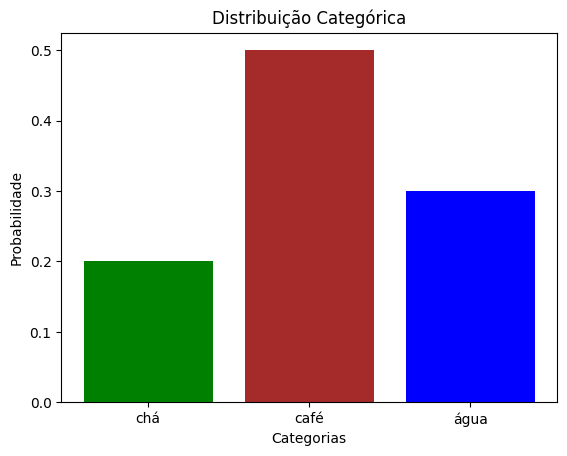

In [ ]:
import matplotlib.pyplot as plt

categories = ['chá', 'café', 'água']
probabilities = [0.2, 0.5, 0.3]

# Criando um gráfico de barras
plt.bar(categories, probabilities, color=['green', 'brown', 'blue'])
plt.xlabel('Categorias')
plt.ylabel('Probabilidade')
plt.title('Distribuição Categórica')
plt.show()

### **5. Amostragem de uma Distribuição Categórica com TensorFlow**
Se estiver usando aprendizado de máquina, você pode usar o TensorFlow para trabalhar com distribuições categóricas.

In [ ]:
import tensorflow as tf

# Definindo as probabilidades
probabilities = [0.2, 0.5, 0.3]

# Criando a distribuição categórica
dist = tf.random.categorical(tf.math.log([probabilities]), num_samples=10)

print("Amostras geradas (índices):", dist.numpy()[0])

Amostras geradas (índices): [1 1 1 0 1 2 1 0 1 2]


## **Distribuição Categórica Em PyTorch**
Em PyTorch, a classe **`torch.distributions.Categorical`** é usada para trabalhar com distribuições categóricas, que modelam variáveis aleatórias discretas que podem assumir um de vários valores (classes ou categorias). Ela é particularmente útil em problemas como classificação, aprendizado por reforço e amostragem de ações discretas.

Uma distribuição categórica é definida por um conjunto de probabilidades associadas a cada categoria. Por exemplo, se temos três categorias $ A, B, C $, as probabilidades podem ser $ [0.2, 0.5, 0.3] $, indicando que a categoria $ B $ tem a maior probabilidade de ser escolhida.

A entrada pode ser fornecida de duas formas:
1. **`probs`**: As probabilidades diretas de cada classe. Devem ser não negativas e somar 1.
2. **`logits`**: Os logit scores, que são transformados internamente em probabilidades usando a função softmax:
   $$
   p_i = \frac{e^{\text{logit}_i}}{\sum_{j} e^{\text{logit}_j}}
   $$
   Aqui, os logits podem ser qualquer número real e **não precisam somar 1**.

---

### **`Categorical(logits)`**

Quando você usa **`Categorical(logits)`**, PyTorch assume que os valores passados são **logits** e converte-os automaticamente em probabilidades usando a função softmax.

#### Propriedades:
- **Entrada flexível**: Os logits podem ser números negativos ou positivos, e PyTorch calcula as probabilidades correspondentes.
- **Evita instabilidade numérica**: Trabalhar diretamente com logits é preferido em vez de probabilidades porque a transformação softmax lida melhor com números grandes ou pequenos.

Alguns exemplos de como trabalhar com distribuições categóricas usando PyTorch.

---

### **1. Criando e Amostrando de uma Distribuição Categórica**
O módulo `torch.distributions.Categorical` é usado para criar uma distribuição categórica.

In [ ]:
# Criar uma distribuição categórica a partir de logits:
import torch
from torch.distributions import Categorical

# Logits para 3 categorias
logits = torch.tensor([2.0, 1.0, 0.1])

# Criar a distribuição categórica
dist = Categorical(logits=logits)

# Obter as probabilidades correspondentes
probs = dist.probs
print("Probabilidades:", probs)
# Output: Probabilidades: tensor([0.6590, 0.2424, 0.0986])

# Log-probabilidade de uma categoria específica
log_prob = dist.log_prob(torch.tensor(0))  # Categoria 0
print("Log-probabilidade da categoria 0:", log_prob)

Probabilidades: tensor([0.6590, 0.2424, 0.0986])
Log-probabilidade da categoria 0: tensor(-0.4170)


In [ ]:
from collections import Counter

categories = ['chá', 'café', 'água']
# Probabilidades das categorias
probabilities = torch.tensor([0.2, 0.5, 0.3])

# Criando a distribuição categórica
categorical_dist = Categorical(probs=probabilities)

# Amostrando 10 vezes
samples = categorical_dist.sample((10,))

print("Amostras geradas (índices):", samples)
count = Counter(samples.numpy())
print("Quantidades:", count)

Amostras geradas (índices): tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 2])
Quantidades: Counter({1: 8, 0: 1, 2: 1})


In [ ]:
# Define a new probability distribution
probs = torch.tensor([0.1, 0.5, 1.7])
dist = Categorical(probs)

# Obter as probabilidades correspondentes
probs_ = dist.probs
print("Probabilidades:", probs_)

# Sample multiple times
samples = [dist.sample().item() for _ in range(1000)]

# Count occurrences of each index
counts = torch.tensor(samples).bincount()
print("Sampled counts:", counts)

Probabilidades: tensor([0.0435, 0.2174, 0.7391])
Sampled counts: tensor([ 47, 221, 732])


In [ ]:
# Define logits (unnormalized log-probabilities)
logits = torch.tensor([0.2, 1.5, 2.7])

# Create the categorical distribution
dist = Categorical(logits=logits)

# Obter as probabilidades correspondentes
probs_ = dist.probs
print("Probabilidades:", probs_)

# Sample multiple times
samples = [dist.sample().item() for _ in range(1000)]

# Count occurrences of each index
counts = torch.tensor(samples).bincount()
print("Sampled counts:", counts)

Probabilidades: tensor([0.0593, 0.2177, 0.7229])
Sampled counts: tensor([ 44, 245, 711])


Let’s get straight into it. When you define a categorical distribution using PyTorch, sampling is as simple as calling `.sample()`. Here’s a quick example to see it in action:

In [ ]:
# Define a probability distribution
probs = torch.tensor([0.2, 0.9, 0.3])
categorical_dist = Categorical(probs)

# Obter as probabilidades correspondentes
probs_ = dist.probs
print("Probabilidades:", probs_)

# Take a sample
sample = categorical_dist.sample()

# Print the sampled index
print(f"Sampled index: {sample.item()}")

Probabilidades: tensor([0.1343, 0.2004, 0.6653])
Sampled index: 1


Here’s what’s happening:

The distribution (probs) has three events with probabilities 0.2, 0.5, and 0.3. When you call `.sample()`, PyTorch randomly picks one of these events based on the defined probabilities. The result is an integer index representing the selected event.

### **2. Calculando a Probabilidade de um Evento**
Podemos calcular a probabilidade logarítmica ou a probabilidade de categorias específicas.

In [ ]:
# Calculando a probabilidade logarítmica da categoria com índice 1 (café)
log_prob = categorical_dist.log_prob(torch.tensor(1))

# Calculando a probabilidade real
prob = log_prob.exp()

print("Probabilidade logarítmica de 'café':", log_prob.item())
print("Probabilidade de 'café':", prob.item())

Probabilidade logarítmica de 'café': -0.6931471824645996
Probabilidade de 'café': 0.5


### **3. Convertendo Índices para Categorias**
Se estiver trabalhando com categorias rotuladas (strings), pode mapear os índices gerados de volta para as categorias.

In [ ]:
# Mapeando índices para categorias
categories = ['chá', 'café', 'água']

# Amostrando 10 vezes
sample_indices = categorical_dist.sample((10,))
sampled_categories = [categories[i] for i in sample_indices]

print("Índices amostrados:", sample_indices)
print("Categorias amostradas:", sampled_categories)

Índices amostrados: tensor([1, 1, 1, 1, 0, 1, 2, 0, 1, 0])
Categorias amostradas: ['café', 'café', 'café', 'café', 'chá', 'café', 'água', 'chá', 'café', 'chá']


### **4. Trabalhando com Gradientes**
Se estiver usando uma distribuição categórica em um modelo que precisa de gradientes (ex.: Reinforcement Learning), PyTorch os calcula automaticamente.

In [ ]:
# Criando probabilidades como um tensor com gradiente
probs = torch.tensor([0.2, 0.5, 0.3], requires_grad=True)

# Criando a distribuição categórica
categorical_dist = Categorical(probs=probs)

# Amostrando uma categoria
sample = categorical_dist.sample()

# Calculando o log de probabilidade da amostra
log_prob = categorical_dist.log_prob(sample)

# Backpropagação para calcular o gradiente
log_prob.backward()

print("Gradientes calculados nas probabilidades:", probs.grad)

Gradientes calculados nas probabilidades: tensor([-1.,  1., -1.])


In [18]:
from torch.distributions import Categorical
import torch

# suppose for 2 actions (CartPole: move left, move right)
# we obtain their logit probabilities from a policy network
policy_net_output = torch.tensor([-1.6094, -0.2231])
# the pdparams are logits, equivalent to probs = [0.2, 0.8]
pdparams = policy_net_output
pd = Categorical(logits=pdparams)

# Obter as probabilidades correspondentes
probs_ = pd.probs
print("Probabilidades:", probs_)

# sample an action
action = pd.sample()
# => tensor(1), or 'move right'
print(action)

# compute the action log probability
ac = pd.log_prob(action)
# => tensor(-0.2231), log probability of 'move right'
print(ac)

Probabilidades: tensor([0.2000, 0.8000])
tensor(1)
tensor(-0.2231)


In [20]:
import numpy as np
np.log(0.8)

-0.2231435513142097

In [9]:
np.exp(-0.2231435513142097)

0.8

Esses exemplos mostram como criar, manipular, calcular probabilidades e integrar distribuições categóricas em fluxos de aprendizado de máquina com PyTorch.

##Algoritmo **REINFORCE**

O algoritmo REINFORCE é bastante simples. Primeiro, inicializa-se a taxa de aprendizado $\alpha$ e constrói-se uma rede de política $\pi_\theta$ com pesos inicializados aleatoriamente.  

Em seguida, itera-se por múltiplos episódios da seguinte maneira: usa-se a rede de política $\pi_\theta$ para gerar uma trajetória $\tau = s_0, a_0, r_0, \dots, s_T, a_T, r_T$ para um episódio. Depois, para cada passo de tempo $t$ na trajetória, calcula-se o retorno $R_t(\tau)$. Usa-se $R_t(\tau)$ para estimar o gradiente da política. Soma-se os gradientes da política para todos os passos de tempo e então usa-se o resultado para atualizar os parâmetros da rede de política $\theta$ (pesos).

**Algoritmo REINFORCE**:

- Inicialize a taxa de aprendizado $\alpha$
- Inicialize os pesos $\theta$ de uma rede de política $\pi_\theta$
- for episódio = 0, ..., MAX_EPISODE do:
  - Amostre uma trajetória $\tau = s_0, a_0, r_0, \dots, s_T, a_T, r_T$
  - set $\nabla_\theta J(\pi_\theta) = 0$
  - for $t = 0, ..., T$ do:
    - $R_t(\tau) = \sum_{t_0=t}^{T} \gamma^{t_0 - t} r_{t_0}$
    - $\nabla_\theta J(\pi_\theta) = \nabla_\theta J(\pi_\theta) + R_t(\tau) \nabla_\theta \log \pi_\theta(a_t | s_t)$
  - end for
  - $\theta = \theta + \alpha \nabla_\theta J(\pi_\theta)$
- end for

É importante que uma trajetória seja descartada após cada atualização de parâmetros — ela não pode ser reutilizada. Isso ocorre porque o **REINFORCE** é um algoritmo **on-policy**. Um algoritmo é **on-policy** se a equação de atualização dos parâmetros depende da política atual. Isso é mostrado na atualização do gradiente, pois o gradiente da política depende diretamente das probabilidades de ação $\pi_\theta(a_t | s_t)$ geradas pela política atual $\pi_\theta$, e não de alguma política passada $\pi_\theta'$.

De forma correspondente, o retorno $R_t(\tau)$, onde $\tau \sim \pi_\theta$, também deve ser gerado pela $\pi_\theta$, caso contrário, as probabilidades de ação serão ajustadas com base em retornos que a política não teria gerado.

## Melhorando o REINFORCE

Nossa formulação do algoritmo **REINFORCE** estima o gradiente da política usando amostragem **Monte Carlo** com uma única trajetória. Essa é uma estimativa não tendenciosa do gradiente da política, mas uma desvantagem dessa abordagem é que ela tem uma alta **variância**. Veremos uma **linha de base** para reduzir a variância da estimativa. Após isso, também discutiremos a **normalização das recompensas** para lidar com o problema de **escala das recompensas**.

Ao usar amostragem Monte Carlo, a estimativa do gradiente da política pode ter alta variância porque os retornos podem variar significativamente de trajetória para trajetória. Isso ocorre devido a três fatores. Primeiro, as ações possuem uma certa aleatoriedade, pois são amostradas de uma distribuição de probabilidade. Segundo, o estado inicial pode variar a cada episódio. Terceiro, a função de transição do ambiente pode ser estocástica.

Uma maneira de reduzir a variância da estimativa é modificar os retornos subtraindo uma linha de base adequada, independente da ação, como mostrado na Equação:

$$
\nabla_\theta J(\pi_\theta) \approx \sum_{t=0}^T \left( R_t(\tau) - b(s_t) \right) \nabla_\theta \log \pi_\theta(a_t | s_t)
$$
onde $b(s_t)$ é a linha de base, uma função que depende apenas do estado $s_t$ e não da ação tomada.

Uma opção para a linha de base é a função de valor $V^\pi$. Essa escolha de linha de base motiva o algoritmo Actor-Critic, uma técnica fundamental em aprendizado por reforço. Nesse contexto, a função de valor $V^\pi$ é usada como uma linha de base para reduzir a variância nas estimativas do gradiente. Essa abordagem é benéfica porque ajuda a melhorar a estabilidade e a eficiência do processo de aprendizado.

Nos métodos Actor-Critic, o "Ator" refere-se à política $ \pi $, que determina as ações do agente, enquanto o "Crítico" refere-se à função de valor $ V^\pi $, que avalia quão boa é a ação escolhida com base na política atual. Ao usar $ V^\pi $ como uma linha de base, o crítico fornece um feedback ao ator, permitindo que o agente melhore sua política ao longo do tempo, ajustando as ações que realiza com base nas recompensas recebidas.

Essa estrutura divide a tarefa em dois componentes:
1. **Ator**: Atualiza a política (o processo de tomada de decisão) com base no feedback do crítico.
2. **Crítico**: Estima a função de valor (quão boa é a ação) e ajuda a reduzir a variância das atualizações da política.

A vantagem de usar a função de valor como linha de base é que ela reduz a variância do gradiente, o que pode levar a um aprendizado mais estável e rápido em comparação com métodos puros de gradiente de política.

Uma outra alternativa é usar os retornos médios ao longo da trajetória. Seja $ b = \frac{1}{T} \sum_{t=0}^{T} R_t(\tau) $.

Observe que essa é uma linha de base constante por trajetória, que não varia com o estado $ s_t $. Ela tem o efeito de centralizar os retornos para cada trajetória em torno de 0. Para cada trajetória, em média, as melhores 50% das ações serão incentivadas, enquanto as outras serão desencorajadas.

##**REINFORCE** em Python
Exemplo simples de implementação do algoritmo **REINFORCE** em Python, que é uma abordagem de **Policy Gradient** para treinamento de agentes em ambientes de reforço. Este código utiliza rede neural básica configurado com uma biblioteca como o **PyTorch** ou **TensorFlow**.

##REINFORCE com **PyTorch**

### Requisitos:
- **PyTorch** instalado (`pip install torch`).
- **gymnasium** instalado (`pip install gymnasium`)
- Um ambiente do OpenAI Gym para testar, como `CartPole-v1`.

In [3]:
pip install gymnasium -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 25.3 MB/s eta 0:00:00


### Exemplo de Código:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym

# Define a rede neural para a política
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        # Rede neural com uma camada oculta de 128 neurônios e ativação Softmax na saída
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),  # Camada densa conectando entrada à camada oculta
            nn.ReLU(),                 # Função de ativação ReLU para não-linearidade
            nn.Linear(128, output_dim),  # Camada conectando a oculta à saída
            nn.Softmax(dim=-1)         # Softmax para gerar distribuição de probabilidade sobre ações
        )

    def forward(self, x):
        return self.fc(x)  # Passa o estado pela rede para obter as probabilidades das ações

# Calcula os retornos descontados para cada passo do episódio
def compute_returns(rewards, gamma=0.99):
    discounted_returns = []  # Lista para armazenar os retornos descontados
    G = 0  # Inicializa o retorno acumulado
    # Itera sobre as recompensas na ordem inversa
    for reward in reversed(rewards):
        G = reward + gamma * G  # Calcula o retorno descontado
        discounted_returns.insert(0, G)  # Insere no início da lista
    return discounted_returns  # Retorna os valores descontados

# Função principal para treinar a política usando REINFORCE
def reinforce(env, policy, optimizer, episodes=1000, gamma=0.99):
    for episode in range(episodes):  # Loop sobre os episódios
        state, _ = env.reset()  # Reinicia o ambiente e obtém o estado inicial
        log_probs = []  # Lista para armazenar os logaritmos das probabilidades
        rewards = []    # Lista para armazenar as recompensas

        done = False  # Indica se o episódio terminou
        while not done:  # Enquanto o episódio não terminar
            # Converte o estado para um tensor para ser usado pela rede
            state_tensor = torch.tensor(state, dtype=torch.float32)
            # Obtém as probabilidades de ações a partir da política
            action_probs = policy(state_tensor)
            # Define a distribuição categórica com base nas probabilidades
            action_dist = torch.distributions.Categorical(action_probs)
            # Seleciona uma ação amostrada da distribuição
            action = action_dist.sample()

            # Executa a ação no ambiente e obtém o próximo estado e recompensa
            state, reward, terminated, truncated, _ = env.step(action.item())
            # Armazena o log da probabilidade da ação tomada
            log_probs.append(action_dist.log_prob(action))
            # Salva a recompensa recebida
            rewards.append(reward)

            # Termina o loop se o episódio estiver terminado ou truncado
            done = terminated or truncated

        # Calcula os retornos descontados para o episódio
        returns = compute_returns(rewards, gamma)
        # Converte os retornos para um tensor
        returns = torch.tensor(returns, dtype=torch.float32)
        # Normaliza os retornos para melhorar a estabilidade numérica
        returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        # Calcula a perda como -somatório dos log-probs ponderados pelos retornos
        loss = -torch.sum(torch.stack(log_probs) * returns)
        loss_hist.append(loss.item())
        # Realiza a etapa de backpropagation
        optimizer.zero_grad()  # Zera os gradientes acumulados
        loss.backward()        # Calcula os gradientes da perda em relação aos parâmetros
        optimizer.step()       # Atualiza os pesos da rede com base nos gradientes

        # Calcula a recompensa total do episódio e exibe
        total_reward = sum(rewards)
        rewards_hist.append(total_reward)
        print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward}, Loss: {loss.item():.2f}")

        # Para o treinamento se o agente resolver o ambiente (alcançar reward_threshold = 500)
        if total_reward >= env.spec.reward_threshold:
            print(f"Solved in {episode + 1} episodes!")
            episodes_ = episode
            break

# Executa o treinamento

# Cria o ambiente CartPole-v1
env = gym.make("CartPole-v1")
# Obtém o número de entradas (dimensão do estado) e saídas (número de ações)
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Inicializa a política (rede neural) e o otimizador
policy = PolicyNetwork(obs_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

loss_hist = []
rewards_hist = []
episodes_ = 1000
# Chama a função para treinar a política usando REINFORCE
reinforce(env, policy, optimizer, episodes=episodes_)
# encerra o ambiente de treinamento
env.close()

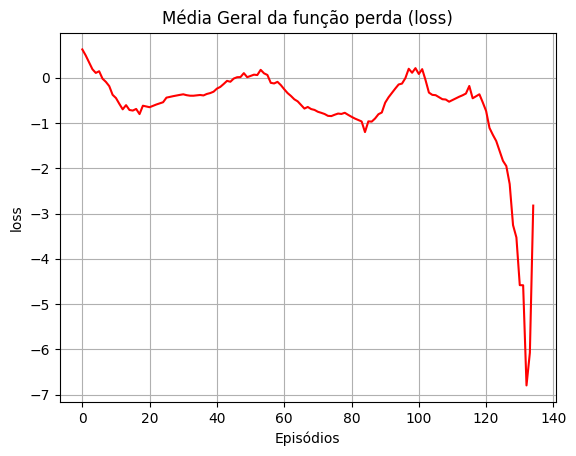

In [ ]:
import matplotlib.pyplot as plt

mean_loss_ = []
for t in range(episodes_-1):
    # calculo a média móvel dos rewards de 30 episódios
    mean_loss_.append(np.mean(loss_hist[max(0, t-30):(t+1)]))

# Plotar o histórico da função perdas (loss)
# plt.plot(loss_hist)
plt.title("Média Geral da função perda (loss)")
plt.xlabel("Episódios")
plt.ylabel("loss")
plt.grid(True)
plt.plot(mean_loss_, color="red")
plt.show()

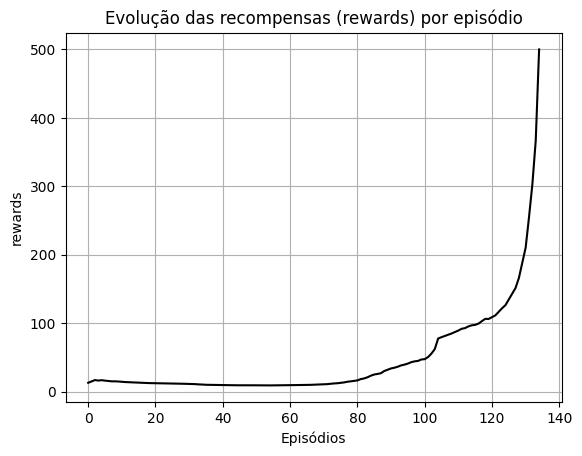

In [ ]:
mean_rewards_ = []
for t in range(episodes_-1):
    # calculo a média móvel dos rewards de 30 episódios
    mean_rewards_.append(np.mean(rewards_hist[max(0, t-30):(t+1)]))

# Plotar o histórico das recompensas
plt.title("Evolução das recompensas (rewards) por episódio")
plt.xlabel("Episódios")
plt.ylabel("rewards")
plt.grid(True)
plt.plot(mean_rewards_, color="black")
plt.show()

### Explicação:

1. **Rede Neural (`PolicyNetwork`)**:
   - Modelo simples com uma camada oculta e ativação `ReLU`.
   - A saída é uma distribuição de probabilidades de ações (softmax).
   - **`PolicyNetwork`**: Define uma rede neural simples com uma camada oculta para a política, que retorna a distribuição de probabilidade de ações possíveis.
2. **`reinforce`**: Implementa o algoritmo REINFORCE. Em cada episódio:
   - O agente escolhe ações com base nas probabilidades da política atual.
   - Ele acumula os logaritmos das probabilidades das ações tomadas (`log_probs`).
   - Ele acumula as recompensas de cada ação para calcular o retorno descontado (`returns`).
3. **Função de Perda**: A perda é calculada como o produto das probabilidades logarítmicas das ações tomadas e os retornos descontados. A ideia é maximizar a expectativa dos retornos ao longo das ações tomadas.
4. **Treinamento**: O modelo é treinado usando o otimizador Adam e a função de perda é minimizada.
2. **Cálculo de Retornos**:
   - Os retornos descontados são calculados usando a fórmula $ G_t = R_t + \gamma G_{t+1} $.

3. **Normalização dos Retornos**:
   - Ajuda na estabilidade do treinamento.

4. **Gradiente da Política**:
   - A perda é calculada como $ -\log(\pi(a|s)) \cdot G_t $.

5. **Treinamento**:
   - O otimizador ajusta os pesos da política para maximizar o retorno esperado.

6. **Critério de Parada**:
   - O treinamento para quando a recompensa total do episódio atinge o limite especificado no ambiente (`reward_threshold`).

---

### Ambiente `CartPole-v1`:
- O agente tenta equilibrar um pêndulo invertido em um carrinho.
- A recompensa máxima é 500.

### Como funciona:

- O agente coleta uma sequência de estados, ações e recompensas.
- Ele calcula o retorno total para cada ação tomada.
- O modelo é atualizado com base na recompensa futura esperada para as ações passadas.
- O algoritmo REINFORCE usa o gradiente das políticas para ajustar a política do agente.

Esse é um exemplo básico que pode ser adaptado, conforme necessário, para ambientes mais complexos ou redes neurais mais profundas.

# Explicação mais detalhada
Este código é uma implementação do algoritmo **REINFORCE** em **PyTorch**, que utiliza um modelo baseado em gradientes de política para treinar um agente no ambiente `CartPole-v1` do **OpenAI Gym**. O objetivo é treinar um agente para equilibrar um pêndulo invertido em um carrinho movendo-o para a esquerda ou direita, com base em uma política aprendida.

### **Importação de bibliotecas**
```python
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
```
- **`torch`**: Usado para construir e treinar redes neurais, lidar com tensores e operações de gradiente.
- **`torch.nn`**: Contém módulos para definir modelos, como camadas de redes neurais.
- **`torch.optim`**: Inclui otimizadores para atualizar os pesos do modelo.
- **`gymnasium`**: Fornece um conjunto de ambientes simulados para aprendizado por reforço, como `CartPole-v1`.
- **`numpy`**: Usado para cálculos numéricos, como manipulação de listas e arrays.

---

### **Rede Neural para a Política (`PolicyNetwork`)**
- **`PolicyNetwork`**: Define a rede neural para o agente (também chamado de "ator"). Ela recebe o estado atual e retorna as probabilidades de selecionar cada ação.
- **O que faz?**
  - Modela a política do agente. A política define a probabilidade de escolher cada ação dado o estado atual.
  - É uma rede neural com:
    - Uma entrada para o estado do ambiente.
    - Uma camada oculta com 128 neurônios e ativação ReLU.
    - Uma camada de saída com `output_size` neurônios (um para cada ação possível).
    - Uma camada de saída com uma ativação softmax para retornar uma distribuição de probabilidade sobre as ações possíveis. A saída é passada por uma função softmax para garantir que as probabilidades somem 1.
  
- **Detalhes do código:**
```python
# Define a rede neural para a política
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        # Rede neural com uma camada oculta de 128 neurônios e ativação Softmax na saída
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),  # Camada densa conectando entrada à camada oculta
            nn.ReLU(),                 # Função de ativação ReLU para não-linearidade
            nn.Linear(128, output_dim),  # Camada conectando a oculta à saída
            nn.Softmax(dim=-1)         # Softmax para gerar distribuição de probabilidade sobre ações
        )

    def forward(self, x):
        return self.fc(x)  # Passa o estado pela rede para obter as probabilidades das ações
```
---

#### **Algoritmo REINFORCE**
- **Como funciona?**
  - Baseia-se na ideia de ajustar a política diretamente para aumentar a probabilidade de ações que levam a altos retornos.
  - A perda é calculada usando:
    $$
    \text{loss} = -\sum_{t} \log(\pi(a_t|s_t)) \cdot G_t
    $$
    Onde:
    - $ \log(\pi(a_t|s_t)) $: Logaritmo da probabilidade da ação $ a_t $.
    - $ G_t $: Retorno descontado para o passo $ t $.

- **Passos principais:**
  1. Executa um episódio completo, armazenando:
     - Logaritmos das probabilidades das ações tomadas.
     - Recompensas recebidas em cada passo.
  2. Calcula os retornos descontados.
  3. Atualiza os pesos da rede neural para maximizar os retornos esperados.

- **Detalhes do código:**
  ```python
  def reinforce(env, policy, optimizer, episodes=1000, gamma=0.99):
      for episode in range(episodes):
          state, _ = env.reset()
          log_probs = []
          rewards = []

          done = False
          while not done:
              state_tensor = torch.tensor(state, dtype=torch.float32)
              action_probs = policy(state_tensor)
              action_dist = torch.distributions.Categorical(action_probs)
              action = action_dist.sample()

              log_probs.append(action_dist.log_prob(action))
              state, reward, done, truncated, _ = env.step(action.item())
              rewards.append(reward)

              if done or truncated:
                  break

          returns = compute_returns(rewards, gamma)
          returns = torch.tensor(returns, dtype=torch.float32)
          returns = (returns - returns.mean()) / (returns.std() + 1e-9)

          loss = -torch.sum(torch.stack(log_probs) * returns)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          total_reward = sum(rewards)
          print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward}")
  ```

---


### **Função REINFORCE**
```python
def reinforce(env, policy_network, optimizer, episodes=1000, gamma=0.99):
```
Essa função implementa o algoritmo REINFORCE, que treina o agente com base no gradiente da política.

#### **Loop principal de episódios**
```python
    for episode in range(episodes):
        state, _ = env.reset()  # Reinicia o ambiente no início do episódio
        done = False
        log_probs = []       # Lista para armazenar logaritmos das probabilidades de ações
        rewards = []         # Lista para armazenar recompensas do episódio
```

- **`env.reset()`**: Reinicia o ambiente e retorna o estado inicial.
- **`log_probs`**: Armazena os logaritmos das probabilidades das ações escolhidas.
- **`rewards`**: Armazena as recompensas recebidas em cada etapa do episódio.

---

#### **Loop interno (interações com o ambiente)**
```python
        while not done:
            state = torch.tensor(state, dtype=torch.float32)  # Converte o estado para tensor
            action_probs = policy_network(state)              # Obtém probabilidades de ação
            dist = torch.distributions.Categorical(action_probs)  # Define distribuição categórica
            action = dist.sample()                            # Amostra uma ação da distribuição
            
            log_probs.append(dist.log_prob(action))           # Armazena log(probabilidade da ação)
            state, reward, done, truncated, _ = env.step(action.item())  # Executa a ação no ambiente
            rewards.append(reward)                            # Armazena a recompensa
```
- A cada interação:
  - O estado atual é convertido para tensor.
  - A rede neural retorna as probabilidades das ações possíveis.
  - Uma ação é escolhida amostrando da distribuição categórica gerada pelas probabilidades.
  - A ação é executada no ambiente, e o próximo estado, a recompensa e o indicador `done` (se o episódio terminou) são retornados.

---

#### **Cálculo dos Retornos Descontados**
- **O que faz?**
  - Calcula os retornos cumulativos descontados ($ G_t $) de cada passo do episódio, usando:
$$
G_t = R_t + \gamma G_{t+1}
$$
  - O parâmetro $ \gamma $ (fator de desconto) ajusta a importância das recompensas futuras.

- **Por que é importante?**
  - Avalia a qualidade das ações passadas em termos das recompensas futuras, incentivando o agente a maximizar o retorno a longo prazo.

- **Detalhes do código:**
  ```python
  def compute_returns(rewards, gamma=0.99):
      discounted_returns = []
      G = 0
      for reward in reversed(rewards):
          G = reward + gamma * G
          discounted_returns.insert(0, G)
      return discounted_returns
  ```
---

#### **Normalização dos retornos**
```python
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-5)
```
- **Por que normalizar?**
  - Para estabilizar o treinamento, já que valores extremos podem levar a gradientes instáveis.
  - Normaliza os retornos para que tenham média 0 e desvio padrão 1.

---

#### **Atualização do modelo**
```python
        loss = -torch.sum(torch.stack(log_probs) * returns)  # Calcula a perda
        optimizer.zero_grad()                               # Zera os gradientes acumulados
        loss.backward()                                     # Computa os gradientes
        optimizer.step()                                    # Atualiza os pesos do modelo
```
- **Perda**:
  - $ \text{loss} = - \sum_t \log(\pi(a_t | s_t)) \cdot G_t $
  - Maximiza a probabilidade das ações que levaram a altos retornos.
- **Otimizador**:
  - Atualiza os pesos da rede neural com base nos gradientes calculados.

---

#### **Log de progresso**
```python
        if episode % 100 == 0:
            print(f"Episode {episode}/{episodes}, Loss: {loss.item()}")
```
- Exibe o progresso a cada 100 episódios, incluindo o valor da função de perda.

---

### **Configuração e Treinamento**
```python
env = gym.make('CartPole-v1')  # Cria o ambiente
input_size = env.observation_space.shape[0]  # Dimensão do estado
output_size = env.action_space.n             # Número de ações possíveis

policy_network = PolicyNetwork(input_size, output_size)  # Cria a rede de política
optimizer = optim.Adam(policy_network.parameters(), lr=1e-2)  # Define o otimizador

reinforce(env, policy_network, optimizer, episodes=1000)  # Treina o agente
```
- **Ambiente**: `CartPole-v1`, onde o objetivo é equilibrar o pêndulo em um carrinho.
- **Rede Neural**: Inicializada com a entrada e a saída correspondentes ao ambiente.
- **Treinamento**: O agente é treinado por 1000 episódios.

---

### **O ambiente CartPole-v1**
- **Descrição:**
  - O agente controla um carrinho que pode se mover para a esquerda ou para a direita para equilibrar um poste vertical.
  - O episódio termina se:
    - O poste inclinar mais de 15 graus.
    - O carrinho se mover para fora dos limites.
    - O agente atingir 500 passos consecutivos equilibrando o poste.

- **Estado:**
  - Um vetor de 4 elementos:
    - Posição do carrinho.
    - Velocidade do carrinho.
    - Ângulo do poste.
    - Velocidade angular do poste.

- **Ações:**
  - 0: Mover o carrinho para a esquerda.
  - 1: Mover o carrinho para a direita.

---

### **Melhorias possíveis**
- **Adição de um Critic:** Usar um estimador para o retorno em vez de calcular o retorno cumulativo.
- **Normalização dos estados:** Para melhorar a estabilidade do treinamento.
- **Exploração:** Implementar um mecanismo para incentivar a exploração inicial, como ruído adicionado às ações.
---
### **Resumo**
Este código treina um agente no ambiente `CartPole-v1` usando o algoritmo REINFORCE. Ele usa uma rede neural para modelar a política, coleta recompensas de interações com o ambiente e ajusta a política para maximizar os retornos acumulados.
O algoritmo **REINFORCE** é uma técnica de aprendizado por reforço baseada em gradiente de política que otimiza diretamente a política de um agente para maximizar o retorno esperado. Abaixo está uma explicação detalhada de cada parte do software:



##Retornos Descontados
Nos algoritmos de aprendizado por reforço (Reinforcement Learning), o cálculo dos **retornos descontados** é uma parte fundamental para determinar o valor de uma sequência de ações em um ambiente. Esse conceito é usado principalmente para avaliar a qualidade de políticas (policy evaluation) e guiar o aprendizado da política ótima.

---

### Definição de Retornos Descontados

O retorno descontado, $ G_t $, é a soma dos **recompensas futuras acumuladas** a partir de um estado $ t $, onde cada recompensa futura é reduzida (descontada) por um fator de desconto $ \gamma $ (chamado **discount factor**, $ 0 \leq \gamma \leq 1 $):

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}
$$

Aqui:
- $ R_{t+1} $: recompensa recebida após tomar uma ação no tempo $ t $.
- $ \gamma $: fator de desconto que determina a importância relativa de recompensas futuras. Valores próximos de 1 dão maior peso às recompensas distantes no futuro, enquanto valores menores priorizam recompensas imediatas.

---

### Como é Feito o Cálculo

1. **Ajuste por Regressão Recursiva**  
   O cálculo do retorno descontado é feito de forma recursiva. Podemos reescrever $ G_t $ como:
   $$
   G_t = R_{t+1} + \gamma G_{t+1}
   $$
   Isso significa que o retorno atual é a soma da recompensa imediata $ R_{t+1} $ mais o retorno descontado do próximo estado $ G_{t+1} $, ajustado pelo fator $ \gamma $.

2. **Implementação Computacional**  
   Em um ambiente discreto com episódios finitos (como em jogos), $ G_t $ pode ser calculado retroativamente (backward pass) a partir do final do episódio. Supondo que o episódio termina em $ T $, o cálculo é:

   - $ G_T = R_T $ (a última recompensa).
   - Para $ t = T-1, T-2, \dots, 0 $:
$$
G_t = R_{t+1} + \gamma G_{t+1}
$$

3. **Em Ambientes Contínuos ou Infinitos**  
   Para ambientes onde os episódios são infinitos (continuos), a soma $ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} $ pode ser aproximada através de truncamento (considerando apenas recompensas futuras dentro de um horizonte finito) ou usando métodos de estimação como o **Temporal Difference Learning**.

---

### Exemplo Prático

Suponha que temos as seguintes recompensas ao longo de um episódio:  
$ R = [1, 2, 3, 4] $ e $ \gamma = 0.9 $.

Cálculo dos retornos descontados $ G_t $:
- Para $ t=3 $: $ G_3 = R_4 = 4 $
- Para $ t=2 $: $ G_2 = R_3 + \gamma G_3 = 3 + 0.9 \cdot 4 = 6.6 $
- Para $ t=1 $: $ G_1 = R_2 + \gamma G_2 = 2 + 0.9 \cdot 6.6 = 7.94 $
- Para $ t=0 $: $ G_0 = R_1 + \gamma G_1 = 1 + 0.9 \cdot 7.94 = 8.15 $

---

### Aplicação nos Algoritmos

O cálculo dos retornos descontados é essencial para:
1. **Monte Carlo Methods**: Usa $ G_t $ para atualizar diretamente os valores de estado ou estado-ação.
2. **Q-Learning e SARSA**: O retorno $ G_t $ é usado para estimar o valor de uma política e ajustar os valores $ Q(s, a) $ gradualmente.
3. **Deep Reinforcement Learning**: Redes neurais aprendem a aproximar $ G_t $ ou $ Q(s, a) $ para guiar decisões em estados complexos.

---

###Cálculo de Retornos Descontados (Simples)
Neste exemplo, calculamos os retornos descontados para uma sequência fixa de recompensas:

In [2]:
import numpy as np

def calcular_retorno_descontado(recompensas, gamma):
    """
    Calcula os retornos descontados para uma sequência de recompensas.

    Args:
        recompensas (list ou np.array): Sequência de recompensas.
        gamma (float): Fator de desconto (0 <= gamma <= 1).

    Returns:
        np.array: Retornos descontados para cada etapa.
    """
    retornos = np.zeros_like(recompensas, dtype=np.float32)
    G = 0
    for t in reversed(range(len(recompensas))):
        G = recompensas[t] + gamma * G
        retornos[t] = G
    return retornos

# Exemplo
recompensas = [1, 2, 3, 4]  # Recompensas ao longo do episódio
gamma = 0.9  # Fator de desconto

retornos_descontados = calcular_retorno_descontado(recompensas, gamma)
print("Recompensas:", recompensas)
print("Retornos descontados:", retornos_descontados)


Recompensas: [1, 2, 3, 4]
Retornos descontados: [8.146 7.94  6.6   4.   ]


###Usando o Ambiente Gym
Agora, aplicamos o cálculo de retornos descontados em um ambiente simples do OpenAI Gym, como CartPole-v1. Nesse caso, jogamos o ambiente, coletamos as recompensas e calculamos os retornos.

In [6]:
import gymnasium as gym
import numpy as np

def calcular_retorno_descontado(recompensas, gamma):
    retornos = np.zeros_like(recompensas, dtype=np.float32)
    retorno_acumulado = 0
    for t in reversed(range(len(recompensas))):
        retorno_acumulado = recompensas[t] + gamma * retorno_acumulado
        retornos[t] = retorno_acumulado
    return retornos

# Inicializa o ambiente
env = gym.make('CartPole-v1')
episodios = 3
gamma = 0.99

for episodio in range(episodios):
    estado, _ = env.reset()
    recompensas = []
    estados = []
    done = False

    while not done:
        # Seleciona uma ação aleatória
        acao = env.action_space.sample()
        proximo_estado, recompensa, done, _, _ = env.step(acao)

        # Armazena as recompensas e estados
        recompensas.append(recompensa)
        estados.append(estado)
        estado = proximo_estado

    # Calcula retornos descontados
    retornos_descontados = calcular_retorno_descontado(recompensas, gamma)
    print(f"Episódio {episodio + 1}:")
    print("Recompensas:", recompensas)
    print("Retornos descontados:", retornos_descontados)

env.close()

Episódio 1:
Recompensas: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Retornos descontados: [8.648275  7.7255306 6.793465  5.851985  4.900995  3.940399  2.9701
 1.99      1.       ]
Episódio 2:
Recompensas: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Retornos descontados: [17.383137  16.548624  15.705681  14.854223  13.994164  13.125419
 12.247898  11.361513  10.466174   9.561792   8.648275   7.7255306
  6.793465   5.851985   4.900995   3.940399   2.9701     1.99
  1.       ]
Episódio 3:
Recompensas: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Retornos descontados: [34.43408   33.771797  33.102825  32.427094  31.744541  31.055092
 30.358679  29.65523   28.944677  28.226946  27.501966  26.769663
 26.029963  25.282791  24.52807   23.765728  22.995686  22.217865
 21.432186

###Loop Aninhado X Recursiva
o Loop Aninhado produz o **mesmo resultado** que o exemplo de cálculo dos retornos descontados usando a abordagem recursiva.

A principal diferença está na implementação:
- **Loop Aninhado** usa um loop aninhado que recalcula o retorno acumulado $ G_t $ para cada estado $ t $ da sequência.
- **O exemplo anterior** calcula os retornos de forma **recursiva e acumulativa** em um único loop, percorrendo a sequência de trás para frente (backward pass).

Ambas as abordagens são válidas, mas a implementação recursiva é **mais eficiente** em termos de complexidade computacional.

---

### Comparação

#### Código do exemplo (recursivo):
```python
def calcular_retorno_descontado(recompensas, gamma):
    retornos = np.zeros_like(recompensas, dtype=np.float32)
    retorno_acumulado = 0
    for t in reversed(range(len(recompensas))):
        retorno_acumulado = recompensas[t] + gamma * retorno_acumulado
        retornos[t] = retorno_acumulado
    return retornos
```

**Complexidade:** $ O(n) $, onde $ n $ é o tamanho da sequência de recompensas. Cada recompensa é processada uma única vez.

---

#### Código Loop Aninhado:
```python
DiscountedReturns = []
for t in range(len(Rewards)):
    G = 0.0
    for k, r in enumerate(Rewards[t:]):
        G += (gamma**k) * r
    DiscountedReturns.append(G)
```

**Complexidade:** $ O(n^2) $. Para cada posição $ t $, há um loop interno que recalcula as potências de $ \gamma $ e soma os valores de recompensa.

---

### Diferenças Práticas

1. **Resultados:**
   Ambos os códigos produzem os mesmos valores de retornos descontados para uma sequência fixa de recompensas e o mesmo $ \gamma $.

2. **Eficiência:**
   - O método **recursivo** (exemplo anterior) é mais eficiente, especialmente para sequências longas.
   - O método **com loops aninhados** é mais direto, mas pode se tornar mais lento em cenários de grande escala, como no treinamento em ambientes de aprendizado por reforço.

---

Neste exemplo, para sequências pequenas, a diferença de desempenho pode ser insignificante. No entanto, para sequências maiores, o método recursivo se torna visivelmente mais rápido.

In [20]:
import numpy as np
import time

# Dados
recompensas = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
gamma = 0.9

# Função recursiva
def calcular_retorno_recursivo(recompensas, gamma):
    retornos = np.zeros_like(recompensas, dtype=np.float32)
    retorno_acumulado = 0
    for t in reversed(range(len(recompensas))):
        retorno_acumulado = recompensas[t] + gamma * retorno_acumulado
        retornos[t] = retorno_acumulado
    return retornos

# Função com loops aninhados
def calcular_retorno_loops(recompensas, gamma):
    retornos = []
    for t in range(len(recompensas)):
        G = 0.0
        for k, r in enumerate(recompensas[t:]):
            G += (gamma**k) * r
        retornos.append(G)
    return retornos

# Medição de tempo
start = time.time()
retornos_recursivo = calcular_retorno_recursivo(recompensas, gamma)
end = time.time()
print(f"Recursivo - Tempo: {end - start:.6f}s, Retornos: {retornos_recursivo}")

start = time.time()
retornos_loops = calcular_retorno_loops(recompensas, gamma)
end = time.time()
print(f"Loops - Tempo: {end - start:.6f}s, Retornos: {retornos_loops}")


Recursivo - Tempo: 0.000170s, Retornos: [30.264313 32.515903 33.90656  34.34062  33.7118   31.902    28.78
 24.2      18.       10.      ]
Loops - Tempo: 0.000096s, Retornos: [30.264311980000006, 32.515902200000006, 33.906558000000004, 34.34062, 33.711800000000004, 31.902, 28.78, 24.200000000000003, 18.0, 10.0]


##Referências
[1] Dong H. **Deep Reinforcement Learning. Fundamentals, Research and Applications**. Springer. 2020.

[2] Laura Graesser, Wah Loon Keng. **Foundations of Deep Reinforcement Learning - Theory and Practice in Python**. Pearson Addison-Wesley. 2023.

[3] https://aws.amazon.com/pt/what-is/reinforcement-learning/

[4] https://www.deeplearningbook.com.br/o-que-e-aprendizagem-por-reforco/

[5] https://www.geeksforgeeks.org/what-is-reinforcement-learning/

[6] https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

[7] https://www.datacamp.com/pt/tutorial/reinforcement-learning-python-introduction

[8] https://towardsdatascience.com/reinforcement-learning-rl-101-with-python-e1aa0d37d43b

[9] https://machinelearningmastery.com/principles-of-reinforcement-learning-an-introduction-with-python/

[10] https://medium.com/turing-talks/aprendizado-por-refor%C3%A7o-1-introdu%C3%A7%C3%A3o-7382ebb641ab

[11] https://www.datacamp.com/tutorial/reinforcement-learning-python-introduction

[12] https://gymnasium.farama.org/introduction/basic_usage/

[13] Sudharsan Ravichandiran. **Deep Reinforcement Learning with Python**. Second Edition. Packt Publishing. 2020.

[14] Morales, M. **Grokking Deep Reinforcement Learning**. Version 11. Manning Publications. 2020.

[15] https://www.learndatasci.com/tutorials/reinforcement-q-learning-scratch-python-openai-gym/

[16] https://github.com/sudharsan13296/Deep-Reinforcement-Learning-With-Python/tree/master